# 🏎️ Nina's F1 Predictions: 2026 Barcelona Grand Prix (Round 7)
## Circuit de Barcelona-Catalunya — June 12-14, 2026

**Model version:** v1.0+Q (early weekend, pre-qualifying)
**Confidence:** MEDIUM — grid is estimated, not yet set

### What This Is

A machine learning model that predicts Formula 1 race results from 24 features — the same kinds of data a race engineer considers when building race strategy. This is the **first cut of the weekend**, made before qualifying: the model trains on every race so far this season (2026 weighted 10x over 2023-2025 history) and estimates the grid from team pace plus driver form. It refreshes as practice and qualifying data arrive — the qualifying update is the biggest jump in accuracy.

> **The grid here is an estimate, so treat this as a baseline.** It will be replaced by the real qualifying result, and the race accuracy check added, as the weekend progresses.


In [1]:
import sys; sys.path.insert(0, '../scripts')
import f1lib
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background'); plt.rcParams['figure.figsize'] = (10, 6)
f1lib.enable_cache('../data/cache')

EVENT, RND, TRACK = 'Barcelona', 7, 'Circuit de Barcelona-Catalunya'
SECTORS = '../data/barcelona_sectors.csv'
PRE_RACE = False
WEATHER = 'auto'

df, weather, lap_stats, advanced, lk = f1lib.load_data('../data')
# If this round is already in the data use its slot; otherwise (pre-race, race not
# yet appended) train on everything available by targeting one past the last race.
_rows = df[(df.Year == 2026) & (df.Round == RND)]
target_seq = int(_rows['race_seq'].iloc[0]) if len(_rows) else int(df['race_seq'].max() + 1)

sec = f1lib.track_sector_deltas(SECTORS)
cp_season = f1lib.season_pace(df, 2026, target_seq)
speeds_2026 = lap_stats[lap_stats.Year == 2026].groupby('Team')['avg_speed_st'].mean().to_dict()

feat = f1lib.engineer_features(df, lap_stats, lk, sec, target_seq, cp_season)
model, loo_mae, residual_std = f1lib.train(feat, target_seq)

print('=' * 60)
print(f'  🤖 XGBOOST v1.0 — 24 features, trained through Round {RND-1}')
print('=' * 60)
print(f'  Training rows: {len(feat[feat.race_seq < target_seq]):,}')
print(f'  Leave-one-out MAE: {loo_mae:.2f} positions (honest)')
print(f'  Residual StdDev:   {residual_std:.2f}')

imp = sorted(zip(f1lib.FEATURE_COLS, model.feature_importances_), key=lambda x: -x[1])
print('\n  Top features:')
for f, s in imp[:8]:
    print(f'    {f:25s} {s:.3f}')


  🤖 XGBOOST v1.0 — 24 features, trained through Round 6
  Training rows: 1,529
  Leave-one-out MAE: 2.41 positions (honest)
  Residual StdDev:   3.06

  Top features:
    grid_position             0.209
    team_pit_strategy         0.077
    sector1_delta             0.072
    car_speed                 0.063
    team_changed              0.058
    car_pace                  0.056
    is_2026                   0.053
    driver_avg_finish         0.047


## 1. Season Pace & Estimated Grid

Qualifying hasn't run yet, so there is no real grid. The model estimates the starting order from team pace (season form blended with any practice that has run) plus each driver's season form, and uses Barcelona's historical sector profile. **The grid below is an estimate** — it will be replaced by the real qualifying result when this page is regenerated on Saturday, which is the single biggest accuracy jump of the weekend.

In [2]:
import fastf1
# Race-day weather. WEATHER is 'auto' (Open-Meteo forecast), 'temp,humidity,rain%'
# (manual), or '' (use the stage's default conditions).
forecast = None
if WEATHER == 'auto':
    _ev = fastf1.get_event(2026, RND)
    _race_date = str(pd.to_datetime(_ev['EventDate']).date())
    forecast = f1lib.fetch_forecast(EVENT, _race_date)
    if forecast:
        print(f"  🌤️ Forecast (Open-Meteo, {_race_date}): {forecast['air_temp']:.0f}°C, "
              f"{forecast['humidity']:.0f}% RH, {forecast['rain_prob']:.0f}% rain")
    else:
        print('  ⚠️ Forecast unavailable — falling back to default conditions.')
elif WEATHER:
    _p = [float(x) for x in WEATHER.split(',')]
    forecast = {'air_temp': _p[0], 'humidity': _p[1], 'rain_prob': _p[2]}
    print(f"  🌤️ Manual forecast: {forecast['air_temp']:.0f}°C, "
          f"{forecast['humidity']:.0f}% RH, {forecast['rain_prob']:.0f}% rain")

wk = f1lib.weekend_preq(2026, EVENT, df, {'pace': cp_season, 'speed': speeds_2026}, sec,
                        forecast=forecast)
wk['race_name'] = EVENT

grid_sorted = sorted(wk['grid'].items(), key=lambda x: x[1])
print('=' * 70)
print(f'  📊 ESTIMATED GRID — 2026 {EVENT} GP  [stage: {wk["stage"]}]')
print('=' * 70)
print(f"\n  {'Est':>3s}  {'Driver':22s}  {'Team':18s}  {'Blend Pace':>10s}")
print('  ' + '-' * 60)
for name, pos in grid_sorted:
    t = wk['team_map'].get(name, '')
    print(f"  P{pos:>2d}  {name:22s}  {t:18s}  P{wk['car_pace'].get(t, 15):>6.1f}")
print("\n  Grid is ESTIMATED from pace + form; real qualifying replaces it Saturday.")

_cond = 'WET' if wk['rain'] else 'DRY'
print(f"\n  🌡️ Race conditions: {wk['temp']:.1f}°C, {wk['humidity']:.0f}% humidity, "
      f"{wk['rain_prob']:.0f}% rain -> {_cond}")
if 0 < wk['rain_prob'] < 100:
    print(f"  Predictions are a {wk['rain_prob']:.0f}% wet / {100-wk['rain_prob']:.0f}% dry blend.")


  🌤️ Forecast (Open-Meteo, 2026-06-14): 29°C, 31% RH, 0% rain


  📊 ESTIMATED GRID — 2026 Barcelona GP  [stage: pre-practice (season form)]

  Est  Driver                  Team                Blend Pace
  ------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes            P   4.1
  P 2  Lewis Hamilton          Ferrari             P   5.2
  P 3  George Russell          Mercedes            P   4.1
  P 4  Charles Leclerc         Ferrari             P   5.2
  P 5  Pierre Gasly            Alpine              P  10.5
  P 6  Oscar Piastri           McLaren             P  10.8
  P 7  Max Verstappen          Red Bull Racing     P  10.8
  P 8  Franco Colapinto        Alpine              P  10.5
  P 9  Lando Norris            McLaren             P  10.8
  P10  Liam Lawson             Racing Bulls        P  11.4
  P11  Isack Hadjar            Red Bull Racing     P  10.8
  P12  Arvid Lindblad          Racing Bulls        P  11.4
  P13  Esteban Ocon            Haas F1 Team        P  12.2
  P14  Oliver Bearman          

## 2. Predicted Finish

Each driver's predicted finishing position, with the inputs that drove it: grid (actual qualifying), car (blended team pace), and the position change the model expects relative to the grid.

In [3]:
preds = f1lib.predict(df, feat, model, lk, wk)

print('=' * 80)
print(f'  🏁 PREDICTED FINISH — 2026 {EVENT} GP')
print('=' * 80)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':18s}  {'Grid':>4s}  {'Pred':>5s}  {'ΔGrid':>5s}")
print('  ' + '-' * 70)
for p in preds:
    d = p['Grid'] - p['Rank']
    ds = f'+{d}' if d > 0 else (f'{d}' if d < 0 else '=')
    print(f"  P{p['Rank']:>2d}  {p['Driver']:22s}  {p['Team']:18s}  P{p['Grid']:>2.0f}  P{p['Predicted']:>4.1f}  {ds:>5s}")


  🏁 PREDICTED FINISH — 2026 Barcelona GP

  Pos  Driver                  Team                Grid   Pred  ΔGrid
  ----------------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes            P 1  P 2.6      =
  P 2  Lewis Hamilton          Ferrari             P 2  P 2.8      =
  P 3  Charles Leclerc         Ferrari             P 4  P 3.6     +1
  P 4  Oscar Piastri           McLaren             P 6  P 4.6     +2
  P 5  Max Verstappen          Red Bull Racing     P 7  P 4.7     +2
  P 6  George Russell          Mercedes            P 3  P 6.5     -3
  P 7  Lando Norris            McLaren             P 9  P 7.4     +2
  P 8  Pierre Gasly            Alpine              P 5  P 8.0     -3
  P 9  Liam Lawson             Racing Bulls        P10  P 8.3     +1
  P10  Arvid Lindblad          Racing Bulls        P12  P 8.5     +2
  P11  Franco Colapinto        Alpine              P 8  P 9.4     -3
  P12  Isack Hadjar            Red Bull Racing     P11  

## 3. Podium Probabilities (10,000 Simulated Races)

Rather than a single outcome, the model simulates the race 10,000 times with realistic randomness — and now models **retirements**: each driver can DNF with their season failure rate, which promotes everyone behind them. That matters most at high-attrition tracks, where a front-runner's mechanical failure reshuffles the order. Add a 33% safety-car chance and grid-dependent chaos (the midfield is messier than the front row), and the result is a probability for each driver.

  Modeled retirements: 4.5 per race (driven by each driver's season DNF rate)

  🎲 PODIUM PROBABILITIES — 2026 Barcelona GP

  Driver                  Team                Grid     Win   Podium    Top5
  ------------------------------------------------------------------------
  Kimi Antonelli          Mercedes            P 1   27.5%    69.3%   88.9%  █████████████
  Lewis Hamilton          Ferrari             P 2   21.6%    58.9%   79.2%  ██████████
  Charles Leclerc         Ferrari             P 4   16.9%    45.0%   67.4%  ████████
  Max Verstappen          Red Bull Racing     P 7   10.8%    34.6%   58.5%  █████
  Oscar Piastri           McLaren             P 6    9.2%    28.1%   46.1%  ████
  Lando Norris            McLaren             P 9    3.4%    11.5%   22.5%  █
  Liam Lawson             Racing Bulls        P10    2.5%     8.8%   18.7%  █
  Arvid Lindblad          Racing Bulls        P12    2.3%     8.7%   18.6%  █
  Franco Colapinto        Alpine              P 8    1.4%     6.5

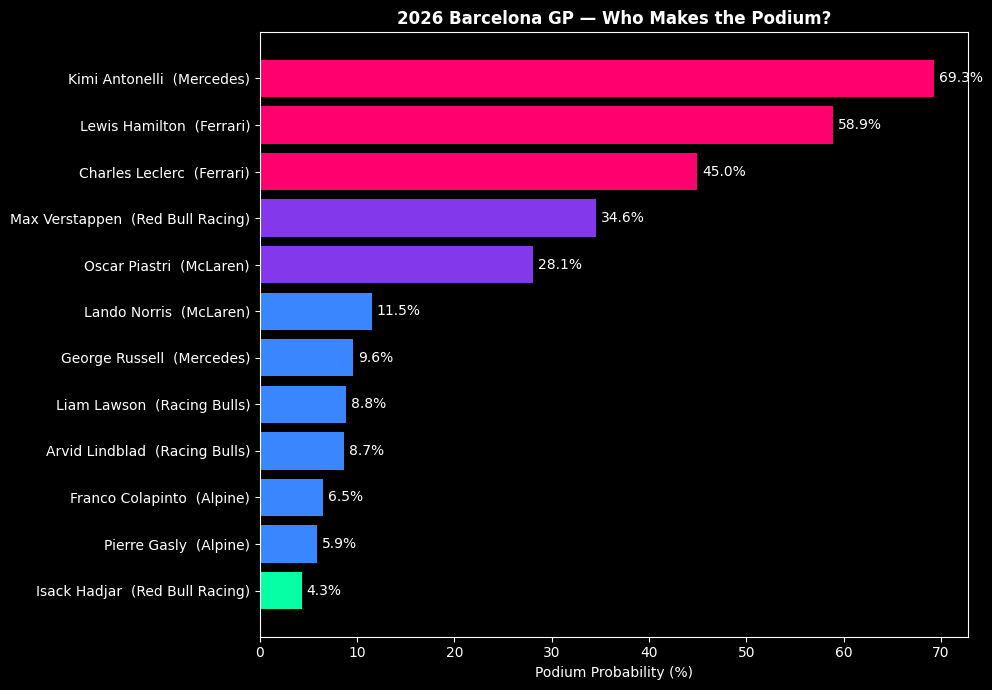

In [4]:
sims = f1lib.simulate(preds, residual_std)
n = sims['n']
print(f"  Modeled retirements: {sum(sims['dnf'].values())/n:.1f} per race (driven by each driver's season DNF rate)\n")
prob = [{'Driver': p['Driver'], 'Team': p['Team'], 'Grid': p['Grid'],
         'Win': sims['win'][p['Driver']]/n*100, 'Podium': sims['podium'][p['Driver']]/n*100,
         'Top5': sims['top5'][p['Driver']]/n*100, 'Top10': sims['top10'][p['Driver']]/n*100}
        for p in preds]
prob_df = pd.DataFrame(prob).sort_values('Win', ascending=False)

print('=' * 80)
print(f'  🎲 PODIUM PROBABILITIES — 2026 {EVENT} GP')
print('=' * 80)
print(f"\n  {'Driver':22s}  {'Team':18s}  {'Grid':>4s}  {'Win':>6s}  {'Podium':>7s}  {'Top5':>6s}")
print('  ' + '-' * 72)
for _, r in prob_df.head(12).iterrows():
    bar = '█' * int(r['Win']/2)
    print(f"  {r['Driver']:22s}  {r['Team']:18s}  P{r['Grid']:>2.0f}  {r['Win']:>5.1f}%  {r['Podium']:>6.1f}%  {r['Top5']:>5.1f}%  {bar}")

fig, ax = plt.subplots(figsize=(10, 7))
t12 = prob_df.head(12).sort_values('Podium')
colors = ['#ff006e' if p > 40 else '#8338ec' if p > 15 else '#3a86ff' if p > 5 else '#06ffa5' for p in t12['Podium']]
bars = ax.barh(t12['Driver'] + '  (' + t12['Team'] + ')', t12['Podium'], color=colors)
for b, v in zip(bars, t12['Podium']):
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Podium Probability (%)')
ax.set_title(f'2026 {EVENT} GP — Who Makes the Podium?', fontweight='bold')
plt.tight_layout(); plt.show()


## 4. What Happens Next

*This is the pre-qualifying baseline for the Barcelona GP. It refreshes through the weekend:*
- *Friday (after practice): rerun `--pre-qualifying` to fold in FP pace.*
- *Saturday (after qualifying): rerun `--pre-race --weather auto` for the real grid — the biggest accuracy jump.*
- *After the race: run `update_data.py` then rerun with no flag to add the official results and accuracy.*